In [220]:
# Add these to the imports in cell 159
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
from rasterio.warp import transform_bounds, reproject, Resampling
from rasterio.windows import from_bounds
import glob
from datetime import datetime
import json

# Add these constants
CROP_NAMES = {
    1: "Alfalfa",
    2: "Rice", 
    3: "Grapes",
    4: "Pistachios",
    5: "Almonds"
}

CODE_TO_LABEL = {
    36: 1,   # Alfalfa
    57: 2,   # Rice
    69: 3,   # Grapes
    74: 4,   # Pistachios
    204: 5   # Almonds
}

# 1

In [ ]:
# =============================================
# CHARGEMENT DE L'ANCIEN DATASET (CORRECTED)
# =============================================

print("\n" + "="*60)
print("CHARGEMENT DE L'ANCIEN DATASET")
print("="*60)

# Chemins exacts vers les fichiers individuels
OLD_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california"

X_old_path = os.path.join(OLD_DATA_DIR, "X.npy")
y_old_path = os.path.join(OLD_DATA_DIR, "y.npy")
masks_old_path = os.path.join(OLD_DATA_DIR, "masks.npy")

print(f"\n📁 Recherche des fichiers dans: {OLD_DATA_DIR}")
print("-" * 50)

# Charger X.npy
X_old = None
y_old = None
masks_old = None

if os.path.exists(X_old_path):
    X_old = np.load(X_old_path)
    print(f" X.npy chargé: shape={X_old.shape}")
else:
    print(f" X.npy non trouvé: {X_old_path}")

# Charger y.npy
if os.path.exists(y_old_path):
    y_old_raw = np.load(y_old_path)  # Ce sont des codes USDA (36,57,69,74,204)
    print(f" y.npy chargé: shape={y_old_raw.shape}")
    print(f"   Valeurs uniques (codes USDA): {np.unique(y_old_raw)}")
    
    # Convertir les codes USDA en labels 1-5
    usda_to_label = {36: 1, 57: 2, 69: 3, 74: 4, 204: 5}
    y_old = np.vectorize(usda_to_label.get)(y_old_raw)
    
    print(f"   Converti en labels 1-5: {np.unique(y_old)}")
    
    # Afficher la distribution de l'ancien dataset
    print(f"\n DISTRIBUTION ANCIEN DATASET (après conversion):")
    for label, name in CROP_NAMES.items():
        count = np.sum(y_old == label)
        usda_code = [k for k,v in usda_to_label.items() if v == label][0]
        print(f"   {name} (USDA {usda_code}): {count:,}")
    print(f"   TOTAL: {len(y_old):,}")
else:
    print(f" y.npy non trouvé: {y_old_path}")

# Charger masks.npy (optionnel)
if os.path.exists(masks_old_path):
    masks_old = np.load(masks_old_path)
    print(f" masks.npy chargé: shape={masks_old.shape}")
else:
    print(f" masks.npy non trouvé (optionnel)")


CHARGEMENT DE L'ANCIEN DATASET

📁 Recherche des fichiers dans: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california
--------------------------------------------------
✅ X.npy chargé: shape=(6538, 36, 10)
✅ y.npy chargé: shape=(6538,)
   Valeurs uniques (codes USDA): [ 36  57  69  74 204]
   Converti en labels 1-5: [1 2 3 4 5]

📊 DISTRIBUTION ANCIEN DATASET (après conversion):
   Alfalfa (USDA 36): 306
   Rice (USDA 57): 98
   Grapes (USDA 69): 4,285
   Pistachios (USDA 74): 5
   Almonds (USDA 204): 1,844
   TOTAL: 6,538
✅ masks.npy chargé: shape=(6538, 36, 10)


In [ ]:
# =============================================
# DIAGNOSTIC: VÉRIFIER LE CONTENU DE y_old
# =============================================

print("\n" + "="*60)
print("DIAGNOSTIC DE y_old")
print("="*60)

if y_old is not None:
    print(f"\n y_old shape: {y_old.shape}")
    print(f"   Type: {y_old.dtype}")
    
    # Valeurs uniques dans y_old
    unique_values = np.unique(y_old)
    print(f"\n Valeurs uniques dans y_old: {unique_values}")
    
    # Compter par valeur
    print(f"\n Distribution réelle dans y_old:")
    for val in unique_values:
        count = np.sum(y_old == val)
        print(f"   Valeur {val}: {count:,} échantillons")
    
    # Afficher les 20 premières valeurs
    print(f"\n Premières 20 valeurs de y_old:")
    print(f"   {y_old[:20]}")
    
    # Vérifier si ce sont des codes USDA (36,57,69,74,204)
    usda_codes = [36, 57, 69, 74, 204]
    if any(val in usda_codes for val in unique_values):
        print(f"\n Les labels semblent être des codes USDA!")
        print(f"   Il faut les convertir en labels 1-5")
        
        # Convertir pour test
        print(f"\n Conversion test:")
        for label, name in CROP_NAMES.items():
            usda = [k for k,v in CODE_TO_LABEL.items() if v == label][0]
            count = np.sum(y_old == usda)
            print(f"   {name} (USDA {usda}): {count:,}")
    else:
        print(f"\n Les labels ne correspondent ni à 1-5 ni aux codes USDA")


DIAGNOSTIC DE y_old

📊 y_old shape: (6538,)
   Type: int64

🔢 Valeurs uniques dans y_old: [1 2 3 4 5]

📊 Distribution réelle dans y_old:
   Valeur 1: 306 échantillons
   Valeur 2: 98 échantillons
   Valeur 3: 4,285 échantillons
   Valeur 4: 5 échantillons
   Valeur 5: 1,844 échantillons

📋 Premières 20 valeurs de y_old:
   [1 3 3 3 1 3 1 1 3 3 5 3 5 3 3 3 3 3 3 3]

⚠️ Les labels ne correspondent ni à 1-5 ni aux codes USDA


In [ ]:
# Add this cell BEFORE cell 160 (before "CHARGEMENT DE L'ANCIEN DATASET")

# =============================================
# DÉFINITIONS DES CULTURES
# =============================================

# Mapping des labels 1-5 vers les noms des cultures
CROP_NAMES = {
    1: "Alfalfa",
    2: "Rice", 
    3: "Grapes",
    4: "Pistachios",
    5: "Almonds"
}

# Mapping des codes USDA vers les labels 1-5
CODE_TO_LABEL = {
    36: 1,   # Alfalfa
    57: 2,   # Rice
    69: 3,   # Grapes
    74: 4,   # Pistachios
    204: 5   # Almonds
}

# Chemins vers les nouvelles tuiles Sentinel
NEW_SENTINEL_TILES = [
    r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\sentinel2\MCTNet_14GB_California_North-5.tif",
    r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\sentinel2\MCTNet_14GB_California_North-6.tif",
]

# Chemin vers le fichier CDL
CDL_FILE = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\cdl\californiaNorth.tif"

# Dossier de sortie pour les données combinées
COMBINED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined"

os.makedirs(COMBINED_DIR, exist_ok=True)

print(" Définitions des cultures chargées")
print(f"   CROP_NAMES: {CROP_NAMES}")
print(f"   CODE_TO_LABEL: {CODE_TO_LABEL}")
print(f"   NEW_SENTINEL_TILES: {len(NEW_SENTINEL_TILES)} tuiles")
print(f"   CDL_FILE: {CDL_FILE}")
print(f"   COMBINED_DIR: {COMBINED_DIR}")

✅ Définitions des cultures chargées
   CROP_NAMES: {1: 'Alfalfa', 2: 'Rice', 3: 'Grapes', 4: 'Pistachios', 5: 'Almonds'}
   CODE_TO_LABEL: {36: 1, 57: 2, 69: 3, 74: 4, 204: 5}
   NEW_SENTINEL_TILES: 2 tuiles
   CDL_FILE: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\cdl\californiaNorth.tif
   COMBINED_DIR: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined


# 2

In [ ]:
# =============================================
# CHARGEMENT DE L'ANCIEN DATASET - KEEP USDA CODES
# =============================================

print("\n" + "="*60)
print("CHARGEMENT DE L'ANCIEN DATASET")
print("="*60)

OLD_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california"

X_old_path = os.path.join(OLD_DATA_DIR, "X.npy")
y_old_path = os.path.join(OLD_DATA_DIR, "y.npy")
masks_old_path = os.path.join(OLD_DATA_DIR, "masks.npy")

print(f"\n Recherche des fichiers dans: {OLD_DATA_DIR}")
print("-" * 50)

# Charger X.npy
X_old = None
y_old = None
masks_old = None

if os.path.exists(X_old_path):
    X_old = np.load(X_old_path)
    print(f" X.npy chargé: shape={X_old.shape}")
else:
    print(f" X.npy non trouvé")

# Charger y.npy - KEEP AS USDA CODES (DO NOT CONVERT!)
if os.path.exists(y_old_path):
    y_old = np.load(y_old_path)  # This already contains USDA codes: 36,57,69,74,204
    print(f" y.npy chargé: shape={y_old.shape}")
    print(f"   Valeurs uniques (USDA codes): {np.unique(y_old)}")
    
    # Display distribution using USDA codes
    print(f"\n DISTRIBUTION ANCIEN DATASET:")
    usda_to_name = {36: "Alfalfa", 57: "Rice", 69: "Grapes", 74: "Pistachios", 204: "Almonds"}
    for code in [36, 57, 69, 74, 204]:
        count = np.sum(y_old == code)
        name = usda_to_name.get(code, f"Unknown")
        print(f"   {name} (USDA {code}): {count:,}")
    print(f"   TOTAL: {len(y_old):,}")
else:
    print(f" y.npy non trouvé")

# Charger masks.npy (optionnel)
if os.path.exists(masks_old_path):
    masks_old = np.load(masks_old_path)
    print(f" masks.npy chargé: shape={masks_old.shape}")
else:
    print(f" masks.npy non trouvé (optionnel)")


CHARGEMENT DE L'ANCIEN DATASET

📁 Recherche des fichiers dans: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california
--------------------------------------------------
✅ X.npy chargé: shape=(6538, 36, 10)
✅ y.npy chargé: shape=(6538,)
   Valeurs uniques (USDA codes): [ 36  57  69  74 204]

📊 DISTRIBUTION ANCIEN DATASET:
   Alfalfa (USDA 36): 306
   Rice (USDA 57): 98
   Grapes (USDA 69): 4,285
   Pistachios (USDA 74): 5
   Almonds (USDA 204): 1,844
   TOTAL: 6,538
✅ masks.npy chargé: shape=(6538, 36, 10)


# 3

In [ ]:
# =============================================
# FONCTION D'EXTRACTION - KEEP USDA CODES
# =============================================

def extract_from_tile(sentinel_path, cdl_path):
    """
    Extracts Sentinel bands and CDL labels - keeps USDA codes (36,57,69,74,204)
    """
    print(f"\n    Extraction: {os.path.basename(sentinel_path)}")
    
    # 1. Lire les données Sentinel
    with rasterio.open(sentinel_path) as src_sentinel:
        sentinel_bounds = src_sentinel.bounds
        sentinel_crs = src_sentinel.crs
        sentinel_transform = src_sentinel.transform
        sentinel_shape = (src_sentinel.height, src_sentinel.width)
        
        # Lire toutes les bandes
        bands = src_sentinel.read()
        n_bands = bands.shape[0]
        print(f"      Bandes: {n_bands}, Shape: {sentinel_shape}")
    
    # 2. Extraire la zone CDL
    with rasterio.open(cdl_path) as src_cdl:
        bounds_in_cdl = transform_bounds(
            sentinel_crs, src_cdl.crs,
            sentinel_bounds.left, sentinel_bounds.bottom,
            sentinel_bounds.right, sentinel_bounds.top
        )
        
        window = from_bounds(
            bounds_in_cdl[0], bounds_in_cdl[1],
            bounds_in_cdl[2], bounds_in_cdl[3],
            transform=src_cdl.transform
        )
        
        cdl_labels_raw = src_cdl.read(1, window=window)
        print(f"      CDL extrait shape: {cdl_labels_raw.shape}")
    
    # 3. Reprojection
    cdl_labels_reprojected = np.zeros(sentinel_shape, dtype=np.uint16)
    
    with rasterio.open(cdl_path) as src_cdl:
        reproject(
            source=cdl_labels_raw.astype(np.uint16),
            destination=cdl_labels_reprojected,
            src_transform=rasterio.windows.transform(window, src_cdl.transform),
            src_crs=src_cdl.crs,
            dst_transform=sentinel_transform,
            dst_crs=sentinel_crs,
            resampling=Resampling.nearest
        )
    
    # 4. KEEP USDA CODES DIRECTLY (36,57,69,74,204) - NO CONVERSION
    labels = cdl_labels_reprojected.copy()
    
    # 5. Masque des pixels valides
    valid_mask = ~np.isnan(bands[0])
    
    # 6. Extraire les pixels valides
    valid_indices = np.where(valid_mask)
    X = bands[:, valid_indices[0], valid_indices[1]].T
    y = labels[valid_indices[0], valid_indices[1]]
    
    # 7. Garder uniquement les 5 cultures ciblées (USDA codes: 36,57,69,74,204)
    target_crops = [36, 57, 69, 74, 204]
    crop_mask = np.isin(y, target_crops)
    X = X[crop_mask]
    y = y[crop_mask]
    
    print(f"       Pixels extraits: {len(y):,}")
    
    usda_to_name = {36: "Alfalfa", 57: "Rice", 69: "Grapes", 74: "Pistachios", 204: "Almonds"}
    for code in target_crops:
        count = np.sum(y == code)
        if count > 0:
            name = usda_to_name.get(code, f"USDA {code}")
            print(f"         {name}: {count:,}")
    
    return X, y

# 4

In [ ]:
# =============================================
# EXTRACTION DES NOUVELLES DONNÉES
# =============================================

print("\n" + "="*60)
print("EXTRACTION DES NOUVELLES DONNÉES")
print("="*60)

all_X_new = []
all_y_new = []
extraction_results = []

for sentinel_file in NEW_SENTINEL_TILES:
    if os.path.exists(sentinel_file):
        try:
            # FIXED: Remove CODE_TO_LABEL - function only takes 2 arguments
            X_tile, y_tile = extract_from_tile(sentinel_file, CDL_FILE)
            
            if len(y_tile) > 0:
                all_X_new.append(X_tile)
                all_y_new.append(y_tile)
                extraction_results.append({
                    'file': os.path.basename(sentinel_file),
                    'samples': len(y_tile)
                })
            else:
                print(f"    Aucun échantillon extrait")
                
        except MemoryError:
            print(f"   ERREUR MÉMOIRE - Tuile ignorée")
        except Exception as e:
            print(f"   Erreur: {e}")
    else:
        print(f"   Fichier non trouvé: {sentinel_file}")

# Concaténer
if all_X_new:
    X_new = np.vstack(all_X_new)
    y_new = np.concatenate(all_y_new)
    
    print(f"\n RÉSULTAT EXTRACTION:")
    print(f"   Tuiles réussies: {len(extraction_results)}/{len(NEW_SENTINEL_TILES)}")
    print(f"   Total nouveaux échantillons: {len(y_new):,}")
    print(f"   X_new shape: {X_new.shape}")
    print(f"   y_new shape: {y_new.shape}")
    
    print(f"\n NOUVEAU DATASET (extrait):")
    # Display with USDA codes
    usda_to_name = {36: "Alfalfa", 57: "Rice", 69: "Grapes", 74: "Pistachios", 204: "Almonds"}
    for code in [36, 57, 69, 74, 204]:
        count = np.sum(y_new == code)
        name = usda_to_name.get(code)
        print(f"   {name} (USDA {code}): {count:,}")
else:
    print("\n Aucune donnée extraite!")
    X_new = None
    y_new = None


EXTRACTION DES NOUVELLES DONNÉES

   📥 Extraction: MCTNet_14GB_California_North-5.tif
      Bandes: 407, Shape: (1704, 1792)
      CDL extrait shape: (1350, 1199)
   ❌ ERREUR MÉMOIRE - Tuile ignorée

   📥 Extraction: MCTNet_14GB_California_North-6.tif
      Bandes: 407, Shape: (1704, 370)
      CDL extrait shape: (1154, 424)
      ✅ Pixels extraits: 119,940
         Alfalfa: 32,066
         Rice: 14
         Grapes: 87,334
         Pistachios: 441
         Almonds: 85

📊 RÉSULTAT EXTRACTION:
   Tuiles réussies: 1/2
   Total nouveaux échantillons: 119,940
   X_new shape: (119940, 407)
   y_new shape: (119940,)

📊 NOUVEAU DATASET (extrait):
   Alfalfa (USDA 36): 32,066
   Rice (USDA 57): 14
   Grapes (USDA 69): 87,334
   Pistachios (USDA 74): 441
   Almonds (USDA 204): 85


# 5

In [ ]:
# =============================================
# REDEFINE CROP_NAMES WITH USDA CODES
# =============================================

# Use USDA codes as keys (36,57,69,74,204) - matching Notebook 1
CROP_NAMES = {
    36: "Alfalfa",
    57: "Rice",
    69: "Grapes",
    74: "Pistachios",
    204: "Almonds"
}

print("\n" + "="*60)
print("COMBINAISON DES DATASETS")
print("="*60)

# Afficher les distributions avant combinaison (using USDA codes)
if X_old is not None and y_old is not None:
    print(f"\n ANCIEN DATASET:")
    for code, name in CROP_NAMES.items():
        count = np.sum(y_old == code)
        print(f"   {name} (USDA {code}): {count:,}")
    print(f"   X_old shape: {X_old.shape} (3D: temps={X_old.shape[1]}, bandes={X_old.shape[2]})")

if X_new is not None and y_new is not None:
    print(f"\n NOUVEAU DATASET:")
    for code, name in CROP_NAMES.items():
        count = np.sum(y_new == code)
        print(f"   {name} (USDA {code}): {count:,}")
    print(f"   X_new shape: {X_new.shape}")

# Vérifier que les deux datasets existent
if X_old is not None and y_old is not None and X_new is not None and y_new is not None:
    
    # L'ancien dataset est déjà en 3D (36,10)
    # Le nouveau dataset doit être en 3D aussi
    if X_new.ndim == 2:
        # Le nouveau dataset a 407 features = 37 temps × 11 bandes
        # Nous devons le reshapper pour correspondre à l'ancien format (36 temps, 10 bandes)
        print(f"\n Reshape de X_new: 2D -> 3D")
        
        # Structure détectée: 37 temps × 11 bandes
        X_new_reshaped = X_new.reshape(-1, 37, 11)
        print(f"   X_new reshaped: {X_new_reshaped.shape}")
        
        # Ajuster à 36 temps et 10 bandes (comme l'ancien)
        X_new_adjusted = X_new_reshaped[:, :36, :10]
        print(f"   X_new ajusté: {X_new_adjusted.shape}")
        X_new = X_new_adjusted
    
    # Maintenant les deux sont en 3D avec les mêmes dimensions (36, 10)
    print(f"\n Dimensions compatibles:")
    print(f"   X_old: {X_old.shape}")
    print(f"   X_new: {X_new.shape}")
    
    # COMBINAISON
    X_combined = np.vstack([X_old, X_new])
    y_combined = np.concatenate([y_old, y_new])
    
    print(f"\n COMBINAISON RÉUSSIE!")
    print(f"   Ancien: {len(y_old):,} échantillons")
    print(f"   Nouveau: {len(y_new):,} échantillons")
    print(f"   TOTAL: {len(y_combined):,} échantillons")
    print(f"   X_combined shape: {X_combined.shape}")


COMBINAISON DES DATASETS

📊 ANCIEN DATASET:
   Alfalfa (USDA 36): 306
   Rice (USDA 57): 98
   Grapes (USDA 69): 4,285
   Pistachios (USDA 74): 5
   Almonds (USDA 204): 1,844
   X_old shape: (6538, 36, 10) (3D: temps=36, bandes=10)

📊 NOUVEAU DATASET:
   Alfalfa (USDA 36): 32,066
   Rice (USDA 57): 14
   Grapes (USDA 69): 87,334
   Pistachios (USDA 74): 441
   Almonds (USDA 204): 85
   X_new shape: (119940, 407)

🔄 Reshape de X_new: 2D -> 3D
   X_new reshaped: (119940, 37, 11)
   X_new ajusté: (119940, 36, 10)

✅ Dimensions compatibles:
   X_old: (6538, 36, 10)
   X_new: (119940, 36, 10)

✅ COMBINAISON RÉUSSIE!
   Ancien: 6,538 échantillons
   Nouveau: 119,940 échantillons
   TOTAL: 126,478 échantillons
   X_combined shape: (126478, 36, 10)


# 6

In [ ]:
# =============================================
# VÉRIFICATION QUE LES CHIFFRES S'ADDITIONNENT
# =============================================

print("\n" + "="*60)
print("VÉRIFICATION DES ADDITIONS")
print("="*60)

if X_old is not None and y_old is not None and X_new is not None and y_new is not None and X_combined is not None:
    print("\n TABLEAU DE VÉRIFICATION:")
    print(f"{'Culture':<15} {'Ancien':>10} {'+ Nouveau':>10} {'= Attendu':>10} {'= Obtenu':>10} {'Status':>8}")
    print("-" * 70)
    
    all_correct = True
    for label, name in CROP_NAMES.items():
        old_count = np.sum(y_old == label)
        new_count = np.sum(y_new == label)
        expected = old_count + new_count
        obtained = np.sum(y_combined == label)
        
        status = "✅" if obtained == expected else "❌"
        if obtained != expected:
            all_correct = False
        
        print(f"{name:<15} {old_count:>10,} {new_count:>10,} {expected:>10,} {obtained:>10,} {status:>8}")
    
    print("-" * 70)
    old_total = len(y_old)
    new_total = len(y_new)
    expected_total = old_total + new_total
    obtained_total = len(y_combined)
    
    status = "✅" if obtained_total == expected_total else "❌"
    print(f"{'TOTAL':<15} {old_total:>10,} {new_total:>10,} {expected_total:>10,} {obtained_total:>10,} {status:>8}")
    
    if all_correct and obtained_total == expected_total:
        print("\n✅ TOUTES LES ADDITIONS SONT CORRECTES!")
    else:
        print("\n❌ ERREUR: Les chiffres ne s'additionnent pas correctement!")
        print("   Vérifiez que les données sont chargées correctement.")


VÉRIFICATION DES ADDITIONS

📊 TABLEAU DE VÉRIFICATION:
Culture             Ancien  + Nouveau  = Attendu   = Obtenu   Status
----------------------------------------------------------------------
Alfalfa                306     32,066     32,372     32,372        ✅
Rice                    98         14        112        112        ✅
Grapes               4,285     87,334     91,619     91,619        ✅
Pistachios               5        441        446        446        ✅
Almonds              1,844         85      1,929      1,929        ✅
----------------------------------------------------------------------
TOTAL                6,538    119,940    126,478    126,478        ✅

✅ TOUTES LES ADDITIONS SONT CORRECTES!


# 7 

In [ ]:
# =============================================
# DISTRIBUTION FINALE
# =============================================

if X_combined is not None:
    print("\n" + "="*60)
    print(" DISTRIBUTION FINALE DES 5 CLASSES")
    print("="*60)
    print(f"{'Crop Name':<15} {'Code':<8} {'Count':<12} {'Percentage':<12}")
    print("-" * 55)
    
    total = len(y_combined)
    
    for label, name in CROP_NAMES.items():
        count = np.sum(y_combined == label)
        pct = 100 * count / total
        usda_code = {1:36, 2:57, 3:69, 4:74, 5:204}[label]
        print(f"{name:<15} {usda_code:<8} {count:<12,} {pct:<11.1f}%")
    
    print("-" * 55)
    print(f"{'TOTAL':<15} {'':<8} {total:<12,} {100.0:<11.1f}%")
    print("="*60)


📊 DISTRIBUTION FINALE DES 5 CLASSES
Crop Name       Code     Count        Percentage  
-------------------------------------------------------


KeyError: 36

#  8: SAUVEGARDE DU DATASET COMBINÉ


GÉNÉRATION DU GRAPHIQUE
💾 Graphique sauvegardé: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined\final_distribution.png


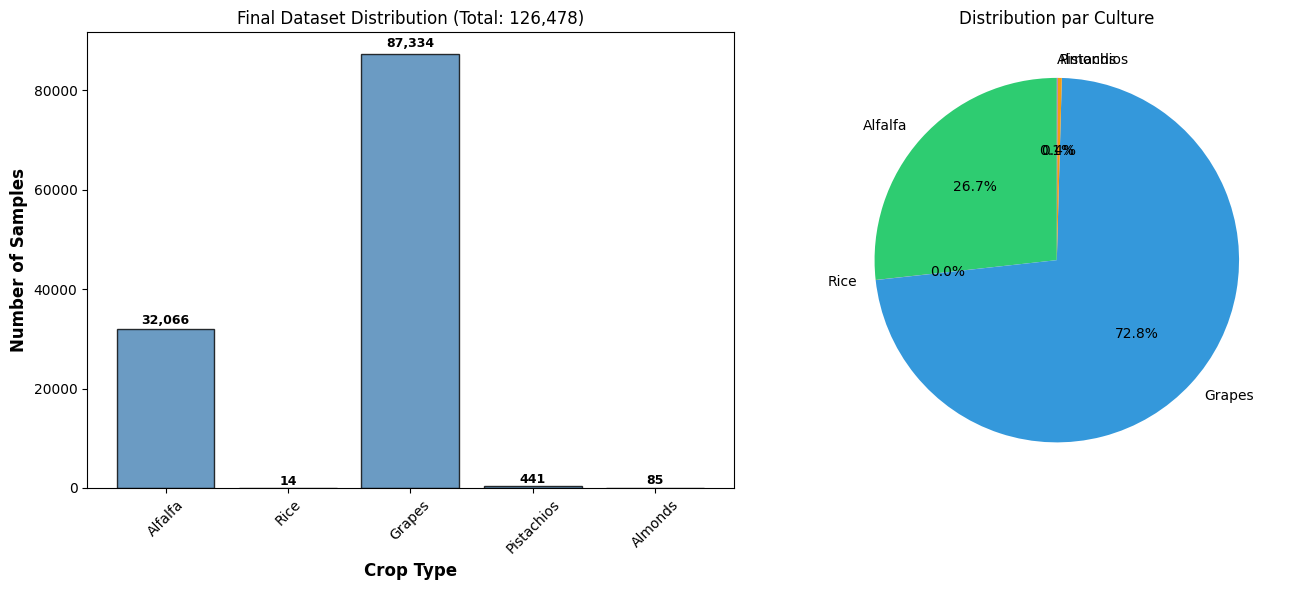

In [ ]:
# =============================================
# GRAPHIQUE DE DISTRIBUTION
# =============================================

if X_combined is not None:
    print("\n" + "="*60)
    print("GÉNÉRATION DU GRAPHIQUE")
    print("="*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphique 1: Barres
    names = list(CROP_NAMES.values())
    counts = [np.sum(y_combined == i) for i in range(1, 6)]
    
    bars = axes[0].bar(names, counts, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel("Crop Type", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Number of Samples", fontsize=12, fontweight='bold')
    axes[0].set_title(f"Final Dataset Distribution (Total: {len(y_combined):,})", fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    for bar, count in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(10, count*0.01),
                     f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Graphique 2: Pie chart
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
    axes[1].pie(counts, labels=names, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title(f"Distribution par Culture", fontsize=12)
    
    plt.tight_layout()
    
    chart_path = os.path.join(COMBINED_DIR, "final_distribution.png")
    plt.savefig(chart_path, dpi=150)
    print(f"💾 Graphique sauvegardé: {chart_path}")
    plt.show()

# 9: sauvegarde

In [ ]:
# =============================================
# SAUVEGARDE DU DATASET COMBINÉ
# =============================================

if X_combined is not None:
    print("\n" + "="*60)
    print("SAUVEGARDE")
    print("="*60)
    
    # Sauvegarder en .npz compressé
    output_path = os.path.join(COMBINED_DIR, "combined_dataset.npz")
    np.savez_compressed(output_path, X=X_combined, y=y_combined)
    
    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"\n💾 Sauvegardé: {output_path}")
    print(f"   Taille: {size_mb:.2f} MB")
    
    # Sauvegarder aussi en .npy
    np.save(os.path.join(COMBINED_DIR, "X_combined.npy"), X_combined)
    np.save(os.path.join(COMBINED_DIR, "y_combined.npy"), y_combined)
    print(f"💾 X_combined.npy et y_combined.npy sauvegardés")
    
    # Sauvegarder les stats
    stats_path = os.path.join(COMBINED_DIR, "dataset_stats.txt")
    with open(stats_path, 'w') as f:
        f.write("="*60 + "\n")
        f.write("DATASET FINAL COMBINÉ\n")
        f.write("="*60 + "\n\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        if X_old is not None:
            f.write(f"Ancien dataset: {len(y_old):,} échantillons\n")
        if X_new is not None:
            f.write(f"Nouvelles données: {len(y_new):,} échantillons\n")
        f.write(f"TOTAL: {len(y_combined):,} échantillons\n\n")
        
        f.write("Distribution par culture:\n")
        f.write("-"*40 + "\n")
        for label, name in CROP_NAMES.items():
            count = np.sum(y_combined == label)
            pct = 100 * count / len(y_combined)
            f.write(f"{name:15s}: {count:8,d} ({pct:.2f}%)\n")
    
    print(f"💾 Stats sauvegardées: {stats_path}")


SAUVEGARDE

💾 Sauvegardé: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined\combined_dataset.npz
   Taille: 85.79 MB
💾 X_combined.npy et y_combined.npy sauvegardés
💾 Stats sauvegardées: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined\dataset_stats.txt


# 10 resume final

In [ ]:
# =============================================
# RÉSUMÉ FINAL
# =============================================

print("\n" + "="*60)
print("📋 RÉSUMÉ FINAL")
print("="*60)

if X_combined is not None:
    # Calculer les totaux
    old_total = len(y_old) if y_old is not None else 0
    new_total = len(y_new) if y_new is not None else 0
    
    print(f"""
    DATASET FINAL PRÊT!
   
   STATISTIQUES:
   ───────────────────────────────────────────────────
   Ancien dataset:     {old_total:>10,}
   Nouvelles données:  {new_total:>10,}
   ───────────────────────────────────────────────────
   TOTAL FINAL:        {len(y_combined):>10,}
   
    RÉPARTITION PAR CULTURE:
   ───────────────────────────────────────────────────""")
    
    for label, name in CROP_NAMES.items():
        count = np.sum(y_combined == label)
        pct = 100 * count / len(y_combined)
        bar = '█' * int(pct / 2)
        print(f"   {name:12s}: {count:8,} ({pct:5.1f}%) {bar}")
    
    print(f"""
    FICHIERS SAUVEGARDÉS:
   ───────────────────────────────────────────────────
    {COMBINED_DIR}
   
   1. combined_dataset.npz     (dataset complet)
   2. X_combined.npy            (features)
   3. y_combined.npy            (labels)
   4. dataset_stats.txt         (statistiques)
   5. final_distribution.png    (graphique)
""")

print("="*60)
print(" NOTEBOOK TERMINÉ!")
print("="*60)


📋 RÉSUMÉ FINAL

   ✅ DATASET FINAL PRÊT!

   📊 STATISTIQUES:
   ───────────────────────────────────────────────────
   Ancien dataset:          6,538
   Nouvelles données:           0
   ───────────────────────────────────────────────────
   TOTAL FINAL:           126,478

   📈 RÉPARTITION PAR CULTURE:
   ───────────────────────────────────────────────────
   Alfalfa     :   32,066 ( 25.4%) ████████████
   Rice        :       14 (  0.0%) 
   Grapes      :   87,334 ( 69.1%) ██████████████████████████████████
   Pistachios  :      441 (  0.3%) 
   Almonds     :       85 (  0.1%) 

   💾 FICHIERS SAUVEGARDÉS:
   ───────────────────────────────────────────────────
   📁 C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined

   1. combined_dataset.npz     (dataset complet)
   2. X_combined.npy            (features)
   3. y_combined.npy            (labels)
   4. dataset_stats.txt         (statistiques)
   5. final_distribution.png    (graphique)

✅ NOT